In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model='llama-3.1-8b-instant',api_key = os.getenv('GROQ_API_KEY'))

In [4]:
class BlogState(TypedDict):
    topic:str
    outline:str
    detailed_blog:str

In [5]:
def gen_outline(state:BlogState)->BlogState:
    title = state['topic']
    prompt = f'For the given topic:{title}, generate an outline in order to write a report'
    response = model.invoke(prompt).content
    state['outline']= response
    return state

In [6]:
def gen_blog(state:BlogState)->BlogState:
    title = state['topic']
    outline = state['outline']
    prompt = f'For the given topic:{title}, based on the outline below, generate a detailed report: \n\n OUTLINE:\n\n {outline}'
    response = model.invoke(prompt).content
    state['detailed_blog']= response
    return state

In [7]:
graph = StateGraph(BlogState)

graph.add_node('gen_outline',gen_outline)
graph.add_node('gen_blog',gen_blog)

graph.add_edge(START,'gen_outline')
graph.add_edge('gen_outline','gen_blog')
graph.add_edge('gen_blog',END)

workflow = graph.compile()

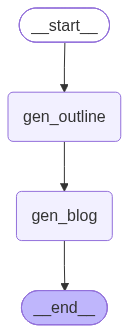

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
initial_state = {'topic':'The journey of ISRO'}
final_state= workflow.invoke(initial_state)
print(final_state)

{'topic': 'The journey of ISRO', 'outline': "**Title:** The Journey of ISRO: A Comprehensive Report\n\n**I. Introduction**\n\n- Brief overview of ISRO and its significance\n- Importance of ISRO in the Indian space program\n- Objectives of the report\n\n**II. Early Years of ISRO (1969-1975)**\n\n- Establishment of ISRO and its first chairman, V.S. Arunachalam\n- First satellite launch: Aryabhata (April 19, 1975)\n- Early successes and challenges faced by ISRO\n\n**III. Growth and Development (1975-1990)**\n\n- Launch of SLV-3 (1979) and its implications\n- Development of PSLV (1993) and its impact on Indian space program\n- Key milestones: Rohini satellite, Bhaskara, and Apple satellites\n\n**IV. International Cooperation and Collaboration (1990-2005)**\n\n- Partnerships with NASA, ESA, and other space agencies\n- Joint missions: INSAT, Megha-Tropiques, and SARAL\n- ISRO's role in international space cooperation\n\n**V. Recent Achievements and Challenges (2005-2020)**\n\n- Launch of Man